# Fine-tuning LLM — Submission PGABL

| Item | Detail |
|---|---|
| **Model Base** | `unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit` |
| **Dataset** | `Ichsan2895/alpaca-gpt4-indonesian` |
| **Teknik** | QLoRA (4-bit, double quantization) |
| **Platform** | Kaggle (GPU T4) |

## 1. Instalasi Package

In [3]:
%%capture
!pip install unsloth
!pip install -U trl peft accelerate bitsandbytes datasets matplotlib

## 2. Autentikasi HuggingFace

Token dibaca dari **Kaggle Secrets** (label: `HF_TOKEN`).

In [4]:
from kaggle_secrets import UserSecretsClient
import os

secrets = UserSecretsClient()
hf_token = secrets.get_secret("HF_TOKEN")
os.environ["HF_TOKEN"] = hf_token

from huggingface_hub import login
login(token=hf_token)
print("Login HuggingFace berhasil.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Login HuggingFace berhasil.


## 3. Load Model dengan QLoRA — Basic Kriteria 1

Model dimuat dengan konfigurasi:
- **4-bit quantization** (`load_in_4bit=True`)
- **Double quantization** diaktifkan secara default oleh Unsloth saat `load_in_4bit=True`
- **LoRA** ditempatkan pada komponen **Multi-Head Attention** (`q_proj`, `k_proj`, `v_proj`, `o_proj`) dan **Feed Forward Network** (`gate_proj`, `up_proj`, `down_proj`)

In [5]:
from unsloth import FastLanguageModel
import torch

MAX_SEQ_LENGTH = 1024
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,          # auto-detect (bf16 jika didukung, else fp16)
    load_in_4bit=True,   # QLoRA — mengaktifkan double quantization
)

print(f"Model '{MODEL_NAME}' berhasil dimuat.")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model 'unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit' berhasil dimuat.


In [6]:
# LoRA Adapter — Eksperimen 1
# r=16 | lora_alpha=16 | lr scheduler=linear

LORA_R_EXP1 = 16
LORA_ALPHA_EXP1 = 16

model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R_EXP1,
    target_modules=[
        # Multi-Head Attention
        "q_proj", "k_proj", "v_proj", "o_proj",
        # Feed Forward Network
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA_EXP1,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
    use_rslora=False,
    loftq_config=None,
)

model.print_trainable_parameters()

Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 4. Persiapan Dataset & Mapping — Basic Kriteria 1

Dataset `Ichsan2895/alpaca-gpt4-indonesian` berformat Alpaca (kolom: `instruction`, `input`, `output`).
Kita mapping ke **ChatML format** yang digunakan Qwen2.5 menggunakan `tokenizer.apply_chat_template`.

In [7]:
from datasets import load_dataset

raw_dataset = load_dataset("Ichsan2895/alpaca-gpt4-indonesian", split="train")

print(f"Total data: {len(raw_dataset)}")
print("\n=== Contoh Data SEBELUM di-mapping ===")
print(raw_dataset[0])

README.md: 0.00B [00:00, ?B/s]

alpaca-gpt4-indonesia.csv:   0%|          | 0.00/41.4M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/49969 [00:00<?, ? examples/s]

Total data: 49969

=== Contoh Data SEBELUM di-mapping ===
{'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


In [8]:
# Cek nama kolom aktual dataset
print("Kolom dataset:", raw_dataset.column_names)
print("Contoh baris pertama:", raw_dataset[0])

SYSTEM_PROMPT = "Anda adalah asisten AI yang helpful, jujur, dan selalu menjawab dalam Bahasa Indonesia."

# Dataset ini memiliki kolom: 'input' (instruksi) dan 'output' (jawaban)
def format_to_chatml(sample):
    """Mapping format dataset ke ChatML (Qwen2.5 Chat Template)."""
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": str(sample["input"]).strip()},
        {"role": "assistant", "content": str(sample["output"]).strip()},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}


dataset_mapped = raw_dataset.map(
    format_to_chatml,
    remove_columns=raw_dataset.column_names,
    num_proc=1,
)

print(f"Mapping selesai. Total: {len(dataset_mapped)} sampel.")

Kolom dataset: ['Unnamed: 0', 'input', 'output']
Contoh baris pertama: {'Unnamed: 0': 1, 'input': 'Saranlah slogan untuk kampanye daur ulang\n', 'output': '1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."\n2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."\n3. "Ubah sampahmu menjadi harta karun - Daur ulang!"\n4. "Daur ulang untuk siklus kehidupan."\n5. "Simpan sumber daya, daur ulang lebih banyak."'}


Map (num_proc=1):   0%|          | 0/49969 [00:00<?, ? examples/s]

Mapping selesai. Total: 49969 sampel.


In [9]:
# Basic requirement: tampilkan satu baris dataset yang sudah terformat
# dengan token spesial (im_start, im_end, dsb.)

print("=== Contoh Data SETELAH di-mapping (dengan token spesial) ===")
print(dataset_mapped[0]["text"])
print("=" * 70)

=== Contoh Data SETELAH di-mapping (dengan token spesial) ===
<|im_start|>system
Anda adalah asisten AI yang helpful, jujur, dan selalu menjawab dalam Bahasa Indonesia.<|im_end|>
<|im_start|>user
Saranlah slogan untuk kampanye daur ulang<|im_end|>
<|im_start|>assistant
1. "Kurangi, gunakan kembali, daur ulang: Bersama untuk masa depan yang lebih hijau."
2. "Daur ulanglah hari ini, untuk masa depan yang lebih baik."
3. "Ubah sampahmu menjadi harta karun - Daur ulang!"
4. "Daur ulang untuk siklus kehidupan."
5. "Simpan sumber daya, daur ulang lebih banyak."<|im_end|>



## 5. Split Train & Validation — Skilled Kriteria 1

Dataset dibagi menjadi **train** (95%) dan **validation** (5%) sebelum training.

In [10]:
split = dataset_mapped.train_test_split(test_size=0.05, seed=42)
train_dataset = split["train"]
eval_dataset  = split["test"]

print(f"Train : {len(train_dataset):,} sampel")
print(f"Valid : {len(eval_dataset):,} sampel")

Train : 47,470 sampel
Valid : 2,499 sampel


## 6. Eksperimen 1 — Skilled Kriteria 1

**Hyperparameter Set A:**
| Parameter | Nilai |
|---|---|
| Learning Rate | `2e-4` |
| LoRA r | `16` |
| LoRA alpha | `16` |
| LR Scheduler | `linear` |
| Warmup Steps | `50` |
| Max Steps | `800` |
| Batch Size (effective) | `2 × 4 = 8` |

In [11]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported

EXP1_CONFIG = {
    "learning_rate": 2e-4,
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 4,
    "max_steps": 800,
    "warmup_steps": 50,
    "lr_scheduler_type": "linear",
    "lora_r": LORA_R_EXP1,
    "lora_alpha": LORA_ALPHA_EXP1,
}

trainer_exp1 = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        per_device_train_batch_size=EXP1_CONFIG["per_device_train_batch_size"],
        gradient_accumulation_steps=EXP1_CONFIG["gradient_accumulation_steps"],
        warmup_steps=EXP1_CONFIG["warmup_steps"],
        max_steps=EXP1_CONFIG["max_steps"],
        learning_rate=EXP1_CONFIG["learning_rate"],
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=50,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=400,
        output_dir="/kaggle/working/outputs_exp1",
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type=EXP1_CONFIG["lr_scheduler_type"],
        seed=42,
        report_to="none",
        dataset_text_field="text",
        max_seq_length=MAX_SEQ_LENGTH,
        padding_free=False,
    ),
)

print(f"Eksperimen 1 siap. Config: {EXP1_CONFIG}")

/kaggle/working/unsloth_compiled_cache/UnslothSFTTrainer.py:643: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  super().__init__(


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/47470 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/2499 [00:00<?, ? examples/s]

Eksperimen 1 siap. Config: {'learning_rate': 0.0002, 'per_device_train_batch_size': 2, 'gradient_accumulation_steps': 4, 'max_steps': 800, 'warmup_steps': 50, 'lr_scheduler_type': 'linear', 'lora_r': 16, 'lora_alpha': 16}


In [12]:
print("Memulai training Eksperimen 1...")
trainer_stats_exp1 = trainer_exp1.train()

# Simpan log history sebelum trainer dihapus
log_history_exp1 = list(trainer_exp1.state.log_history)

print("\nEksperimen 1 selesai!")
print(f"Runtime: {trainer_stats_exp1.metrics['train_runtime']:.1f} detik")
print(f"Samples/detik: {trainer_stats_exp1.metrics['train_samples_per_second']:.2f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Memulai training Eksperimen 1...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,1.294629,1.252753
200,1.258832,1.229377
300,1.252740,1.215587
400,1.201227,1.205198
500,1.186892,1.196718
600,1.214505,1.190599
700,1.224264,1.185943
800,1.210819,1.183907


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


Eksperimen 1 selesai!
Runtime: 4612.5 detik
Samples/detik: 1.39


## 7. Eksperimen 2 — Skilled Kriteria 1

Sebelum eksperimen 2, model base dimuat ulang dari awal agar bobot LoRA tidak terpengaruh eksperimen 1.

**Hyperparameter Set B:**
| Parameter | Nilai |
|---|---|
| Learning Rate | `5e-5` (lebih kecil) |
| LoRA r | `32` (lebih besar) |
| LoRA alpha | `64` |
| LR Scheduler | `cosine` |
| Warmup Steps | `80` |
| Max Steps | `800` |
| Batch Size (effective) | `2 × 4 = 8` |

In [13]:
import gc

# Bebaskan memori dari eksperimen 1
del trainer_exp1
torch.cuda.empty_cache()
gc.collect()

print("Memori dibersihkan. Memuat ulang model untuk Eksperimen 2...")

model2, tokenizer2 = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=True,
)

LORA_R_EXP2    = 32
LORA_ALPHA_EXP2 = 64

model2 = FastLanguageModel.get_peft_model(
    model2,
    r=LORA_R_EXP2,
    target_modules=[
        # Multi-Head Attention
        "q_proj", "k_proj", "v_proj", "o_proj",
        # Feed Forward Network
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA_EXP2,
    lora_dropout=0.05,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=42,
)

model2.print_trainable_parameters()
print("Model untuk Eksperimen 2 siap.")

Memori dibersihkan. Memuat ulang model untuk Eksperimen 2...
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.6.8 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


trainable params: 36,929,536 || all params: 1,580,643,840 || trainable%: 2.3364
Model untuk Eksperimen 2 siap.


In [14]:
EXP2_CONFIG = {
    "learning_rate": 5e-5,
    "per_device_train_batch_size": 2,
    "gradient_accumulation_steps": 4,
    "max_steps": 800,
    "warmup_steps": 80,
    "lr_scheduler_type": "cosine",
    "lora_r": LORA_R_EXP2,
    "lora_alpha": LORA_ALPHA_EXP2,
}

trainer_exp2 = SFTTrainer(
    model=model2,
    tokenizer=tokenizer2,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    args=SFTConfig(
        per_device_train_batch_size=EXP2_CONFIG["per_device_train_batch_size"],
        gradient_accumulation_steps=EXP2_CONFIG["gradient_accumulation_steps"],
        warmup_steps=EXP2_CONFIG["warmup_steps"],
        max_steps=EXP2_CONFIG["max_steps"],
        learning_rate=EXP2_CONFIG["learning_rate"],
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
        logging_steps=50,
        eval_strategy="steps",
        eval_steps=100,
        save_strategy="steps",
        save_steps=400,
        output_dir="/kaggle/working/outputs_exp2",
        optim="adamw_8bit",
        weight_decay=0.01,
        lr_scheduler_type=EXP2_CONFIG["lr_scheduler_type"],
        seed=42,
        report_to="none",
        dataset_text_field="text",
        max_seq_length=MAX_SEQ_LENGTH,
        padding_free=False,
    ),
)

print(f"Eksperimen 2 siap. Config: {EXP2_CONFIG}")

/kaggle/working/unsloth_compiled_cache/UnslothSFTTrainer.py:643: FutureWarning: The default `loss_type` will change from `'nll'` to `'chunked_nll'` in TRL 1.7. For standard models this is transparent (same math, lower memory) and no action is needed — you'll get the new default automatically on upgrade. If you use a custom model, check ahead of time that `loss_type='chunked_nll'` runs and yields the same loss as `'nll'`; if it doesn't, pin `loss_type='nll'` to keep the current behavior and please open an issue at https://github.com/huggingface/trl/issues so we can address the edge case.
  super().__init__(


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/47470 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/2499 [00:00<?, ? examples/s]

Eksperimen 2 siap. Config: {'learning_rate': 5e-05, 'per_device_train_batch_size': 2, 'gradient_accumulation_steps': 4, 'max_steps': 800, 'warmup_steps': 80, 'lr_scheduler_type': 'cosine', 'lora_r': 32, 'lora_alpha': 64}


In [15]:
print("Memulai training Eksperimen 2...")
trainer_stats_exp2 = trainer_exp2.train()

log_history_exp2 = list(trainer_exp2.state.log_history)

print("\nEksperimen 2 selesai!")
print(f"Runtime: {trainer_stats_exp2.metrics['train_runtime']:.1f} detik")
print(f"Samples/detik: {trainer_stats_exp2.metrics['train_samples_per_second']:.2f}")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Memulai training Eksperimen 2...


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 47,470 | Num Epochs = 1 | Total steps = 800
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 36,929,536 of 1,580,643,840 (2.34% trained)


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
100,1.306091,1.259802
200,1.263254,1.233966
300,1.256354,1.219480
400,1.204877,1.209108
500,1.190964,1.201119
600,1.220081,1.196399
700,1.231910,1.194099
800,1.221009,1.193678


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


Eksperimen 2 selesai!
Runtime: 5198.9 detik
Samples/detik: 1.23


## 8. Perbandingan Loss Kurva — Skilled Kriteria 1

Membandingkan **train loss** dan **eval loss** dari kedua eksperimen untuk menentukan kombinasi hyperparameter terbaik (loss terendah tanpa overfitting).

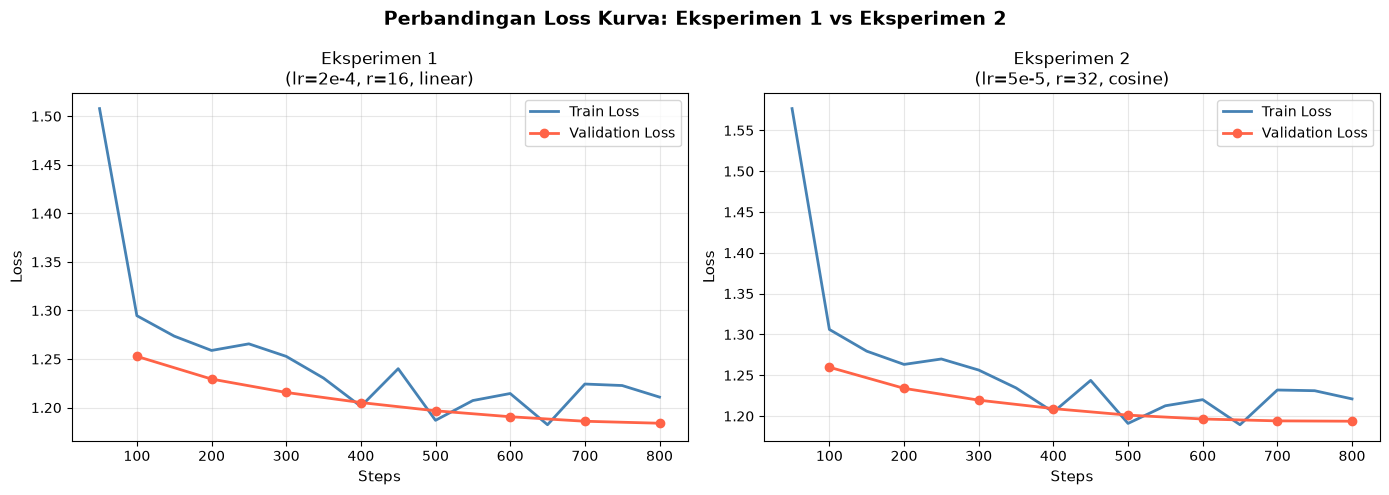

Grafik loss tersimpan: /kaggle/working/loss_comparison.png


In [16]:
import matplotlib.pyplot as plt


def extract_losses(log_history):
    train_steps, train_losses = [], []
    eval_steps, eval_losses   = [], []
    for entry in log_history:
        if "loss" in entry and "eval_loss" not in entry:
            train_steps.append(entry["step"])
            train_losses.append(entry["loss"])
        if "eval_loss" in entry:
            eval_steps.append(entry["step"])
            eval_losses.append(entry["eval_loss"])
    return train_steps, train_losses, eval_steps, eval_losses


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Perbandingan Loss Kurva: Eksperimen 1 vs Eksperimen 2", fontsize=14, fontweight="bold")

experiments = [
    (axes[0], log_history_exp1, EXP1_CONFIG, "Eksperimen 1\n(lr=2e-4, r=16, linear)"),
    (axes[1], log_history_exp2, EXP2_CONFIG, "Eksperimen 2\n(lr=5e-5, r=32, cosine)"),
]

for ax, log_history, config, title in experiments:
    t_steps, t_losses, e_steps, e_losses = extract_losses(log_history)
    ax.plot(t_steps, t_losses, label="Train Loss",      color="steelblue",   linewidth=2)
    ax.plot(e_steps, e_losses, label="Validation Loss", color="tomato", marker="o", linewidth=2)
    ax.set_xlabel("Steps",  fontsize=11)
    ax.set_ylabel("Loss",   fontsize=11)
    ax.set_title(title,     fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafik loss tersimpan: /kaggle/working/loss_comparison.png")

In [17]:
# Tentukan model terbaik berdasarkan eval loss akhir
def get_final_eval_loss(log_history):
    eval_losses = [e["eval_loss"] for e in log_history if "eval_loss" in e]
    return eval_losses[-1] if eval_losses else float("inf")


final_eval_exp1 = get_final_eval_loss(log_history_exp1)
final_eval_exp2 = get_final_eval_loss(log_history_exp2)

print(f"Final Validation Loss — Eksperimen 1: {final_eval_exp1:.4f}")
print(f"Final Validation Loss — Eksperimen 2: {final_eval_exp2:.4f}")

if final_eval_exp1 <= final_eval_exp2:
    best_model, best_tokenizer, best_exp = model,  tokenizer,  "Eksperimen 1"
else:
    best_model, best_tokenizer, best_exp = model2, tokenizer2, "Eksperimen 2"

print(f"\nModel terbaik: {best_exp} (eval loss lebih rendah)")

Final Validation Loss — Eksperimen 1: 1.1839
Final Validation Loss — Eksperimen 2: 1.1937

Model terbaik: Eksperimen 1 (eval loss lebih rendah)


## 9. Push Model ke HuggingFace — Basic Kriteria 1

Model terbaik di-push ke HuggingFace menggunakan metode `merged_16bit` sesuai ketentuan.

In [18]:
# ===== GANTI INI =====
HF_USERNAME = "anggapradana"          # username HuggingFace kamu
REPO_NAME   = "qwen2-5-1-5b-alpaca-id" # nama repo bebas
# =====================

FULL_REPO = f"{HF_USERNAME}/{REPO_NAME}"

print(f"Mendorong model ke: https://huggingface.co/{FULL_REPO}")
print("Proses ini memakan waktu beberapa menit...")

best_model.push_to_hub_merged(
    FULL_REPO,
    best_tokenizer,
    save_method="merged_16bit",
    token=hf_token,
)

print(f"\nModel berhasil di-push ke HuggingFace!")
print(f"Link: https://huggingface.co/{FULL_REPO}")

Mendorong model ke: https://huggingface.co/anggapradana/qwen2-5-1-5b-alpaca-id
Proses ini memakan waktu beberapa menit...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in anggapradana/qwen2-5-1-5b-alpaca-id/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

Unsloth: Merging weights into 16bit:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [00:46<00:00, 46.10s/it]


Unsloth: Merge process complete. Saved to `/kaggle/working/anggapradana/qwen2-5-1-5b-alpaca-id`

Model berhasil di-push ke HuggingFace!
Link: https://huggingface.co/anggapradana/qwen2-5-1-5b-alpaca-id


In [19]:
# Simpan link ke file txt (wajib disertakan dalam submission)
link = f"https://huggingface.co/{FULL_REPO}\n"

with open("/kaggle/working/link_huggingface.txt", "w") as f:
    f.write(link)

print(f"Link tersimpan di: /kaggle/working/link_huggingface.txt")
print(f"Isi: {link.strip()}")

Link tersimpan di: /kaggle/working/link_huggingface.txt
Isi: https://huggingface.co/anggapradana/qwen2-5-1-5b-alpaca-id


## Ringkasan Submission

| Kriteria | Status |
|---|---|
| Dataset mapping ke Chat Template (dengan token spesial) | ✅ |
| QLoRA 4-bit + double quantization | ✅ |
| LoRA pada Multi-Head Attention & Feed Forward Network | ✅ |
| SFTTrainer ≥ 800 steps (Eksperimen 1 + 2, masing-masing 800 steps) | ✅ |
| Push model ke HuggingFace (merged_16bit) | ✅ |
| Train/Validation split | ✅ |
| eval_strategy="steps" + logging | ✅ |
| 2 eksperimen hyperparameter + perbandingan loss kurva | ✅ |

**File output:**
- `/kaggle/working/link_huggingface.txt` — link model HuggingFace
- `/kaggle/working/loss_comparison.png` — grafik perbandingan loss

> Model hasil fine-tuning ini akan digunakan pada notebook **GRPO** dan **RAG**.